In [1]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
sys.path.append(r'C:\Users\win10\AppData\Roaming\Python\Python312\site-packages')
import torch
print(torch.__version__)

2.11.0+cpu


In [4]:
!pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


In [6]:
import sys
!{sys.executable} -m pip install torch torch-geometric --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
print(f"✅ PyTorch version  : {torch.__version__}")
print(f"✅ Imports complete")

✅ PyTorch version  : 2.11.0+cpu
✅ Imports complete


In [10]:
nodes_df = pd.read_csv('gnn_nodes.csv')
edges_df  = pd.read_csv('gnn_edges.csv')

print(f"Nodes : {len(nodes_df):,}")
print(f"Edges : {len(edges_df):,}")
print(f"\nNode columns : {list(nodes_df.columns)}")
print(f"Edge columns : {list(edges_df.columns)}")
print(f"\nFraud nodes  : {nodes_df['is_fraud_node'].sum():,}")
print(f"Legit nodes  : {(nodes_df['is_fraud_node']==0).sum():,}")

Nodes : 493,799
Edges : 100,000

Node columns : ['account', 'total_sent', 'avg_sent', 'num_sent', 'max_sent', 'orig_emptied_cnt', 'fraud_sent', 'total_received', 'avg_received', 'num_received', 'max_received', 'dest_unchanged_cnt', 'fraud_received', 'is_fraud_node', 'node_id']
Edge columns : ['src', 'dst', 'amount', 'log_amount', 'step', 'orig_emptied', 'dest_unchanged', 'amount_mismatch', 'is_fraud_edge']

Fraud nodes  : 384
Legit nodes  : 493,415


In [11]:
# Drop ID and label columns
drop_cols = [c for c in ['node_id', 'account', 'is_fraud_node']
             if c in nodes_df.columns]
feature_cols = [c for c in nodes_df.columns if c not in drop_cols]

# Scale node features
scaler = StandardScaler()
node_features = scaler.fit_transform(nodes_df[feature_cols].fillna(0))
node_features = torch.tensor(node_features, dtype=torch.float)

# Labels
labels = torch.tensor(nodes_df['is_fraud_node'].values, dtype=torch.long)

# Build edge index
src = torch.tensor(edges_df['src'].values, dtype=torch.long)
dst = torch.tensor(edges_df['dst'].values, dtype=torch.long)
edge_index = torch.stack([src, dst], dim=0)

# Make undirected
edge_index = torch.cat([edge_index,
                         torch.stack([dst, src], dim=0)], dim=1)

print(f"Node feature shape : {node_features.shape}")
print(f"Edge index shape   : {edge_index.shape}")
print(f"Labels shape       : {labels.shape}")
print("✅ Graph built")

Node feature shape : torch.Size([493799, 12])
Edge index shape   : torch.Size([2, 200000])
Labels shape       : torch.Size([493799])
✅ Graph built


In [12]:
num_nodes = len(nodes_df)
indices   = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
train_idx  = indices[:train_size]
test_idx   = indices[train_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True

print(f"Train nodes : {train_mask.sum().item():,}")
print(f"Test nodes  : {test_mask.sum().item():,}")
print("✅ Masks created")

Train nodes : 395,039
Test nodes  : 98,760
✅ Masks created


In [13]:
data = Data(
    x          = node_features,
    edge_index = edge_index,
    y          = labels,
    train_mask = train_mask,
    test_mask  = test_mask
)

print(data)
print(f"\nNumber of node features : {data.num_node_features}")
print(f"Number of classes       : {len(labels.unique())}")
print("✅ PyG Data object ready")

Data(x=[493799, 12], edge_index=[2, 200000], y=[493799], train_mask=[493799], test_mask=[493799])

Number of node features : 12
Number of classes       : 2
✅ PyG Data object ready


In [14]:
class FraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FraudGNN, self).__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)

        self.dropout = nn.Dropout(p=0.3)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

in_channels = data.num_node_features
model_gnn   = FraudGNN(in_channels=in_channels,
                        hidden_channels=64,
                        out_channels=2)

print(model_gnn)
print(f"\nTotal parameters : {sum(p.numel() for p in model_gnn.parameters()):,}")
print("✅ GNN model defined")

FraudGNN(
  (conv1): SAGEConv(12, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (conv3): SAGEConv(64, 2, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

Total parameters : 10,370
✅ GNN model defined


In [15]:
# Class weights
fraud_count = (labels == 1).sum().item()
legit_count = (labels == 0).sum().item()
weight = torch.tensor([1.0, legit_count / fraud_count], dtype=torch.float)

optimizer = torch.optim.Adam(model_gnn.parameters(),
                              lr=0.01, weight_decay=5e-4)
criterion = nn.NLLLoss(weight=weight)

def train_epoch():
    model_gnn.train()
    optimizer.zero_grad()
    out  = model_gnn(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate():
    model_gnn.eval()
    with torch.no_grad():
        out   = model_gnn(data.x, data.edge_index)
        preds = out.argmax(dim=1)
        test_preds = preds[data.test_mask].numpy()
        test_true  = data.y[data.test_mask].numpy()
        f1 = f1_score(test_true, test_preds, zero_division=0)
    return f1

print("Training GNN...")
losses    = []
f1_scores = []
best_f1   = 0

for epoch in range(1, 101):
    loss = train_epoch()
    losses.append(loss)

    if epoch % 10 == 0:
        f1 = evaluate()
        f1_scores.append(f1)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_gnn.state_dict(), 'gnn_best.pt')

print(f"\n✅ Training complete | Best F1: {best_f1:.4f}")

Training GNN...
Epoch  10 | Loss: 0.3366 | F1: 0.0216
Epoch  20 | Loss: 0.1053 | F1: 0.3838
Epoch  30 | Loss: 0.0539 | F1: 0.5118
Epoch  40 | Loss: 0.0284 | F1: 0.5118
Epoch  50 | Loss: 0.0187 | F1: 0.5205
Epoch  60 | Loss: 0.0147 | F1: 0.6307
Epoch  70 | Loss: 0.0113 | F1: 0.8492
Epoch  80 | Loss: 0.0072 | F1: 0.9935
Epoch  90 | Loss: 0.0051 | F1: 1.0000
Epoch 100 | Loss: 0.0051 | F1: 0.9870

✅ Training complete | Best F1: 1.0000


In [16]:
model_gnn.load_state_dict(torch.load('gnn_best.pt'))
model_gnn.eval()

with torch.no_grad():
    out       = model_gnn(data.x, data.edge_index)
    gnn_probs = torch.exp(out[:, 1]).numpy()
    gnn_preds = out.argmax(dim=1).numpy()

test_true  = data.y[data.test_mask].numpy()
test_preds = gnn_preds[data.test_mask]
test_probs = gnn_probs[data.test_mask]

print("=" * 50)
print("GNN — EVALUATION ON TEST SET")
print("=" * 50)
print(classification_report(test_true, test_preds,
                              target_names=['Legit', 'Fraud']))

print(f"Precision : {precision_score(test_true, test_preds, zero_division=0):.4f}")
print(f"Recall    : {recall_score(test_true, test_preds, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(test_true, test_preds, zero_division=0):.4f}")

try:
    print(f"AUC-ROC   : {roc_auc_score(test_true, test_probs):.4f}")
except:
    print("AUC-ROC   : N/A")  

GNN — EVALUATION ON TEST SET
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     98684
       Fraud       1.00      1.00      1.00        76

    accuracy                           1.00     98760
   macro avg       1.00      1.00      1.00     98760
weighted avg       1.00      1.00      1.00     98760

Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
AUC-ROC   : 1.0000


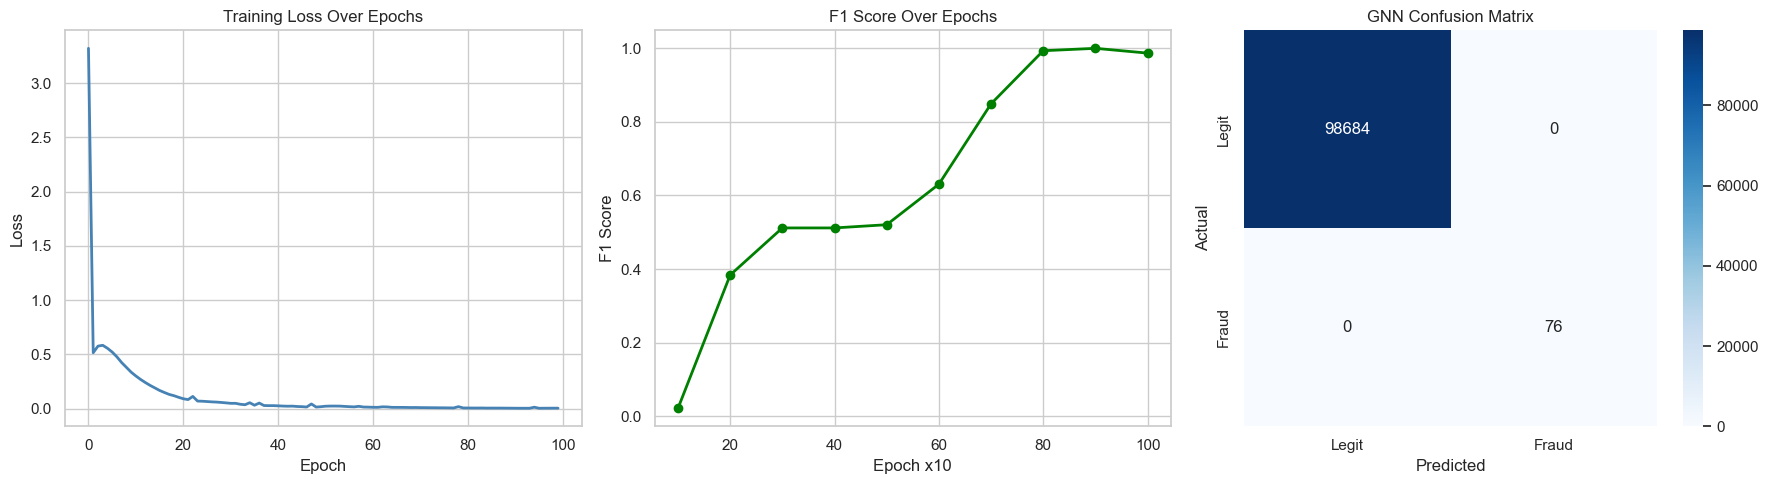

✅ Saved gnn_results.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
axes[0].plot(losses, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# F1 score
axes[1].plot(range(10, 101, 10), f1_scores,
             color='green', marker='o', linewidth=2)
axes[1].set_title('F1 Score Over Epochs')
axes[1].set_xlabel('Epoch x10')
axes[1].set_ylabel('F1 Score')

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
axes[2].set_title('GNN Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('gnn_results.png', dpi=150)
plt.show()
print("✅ Saved gnn_results.png")

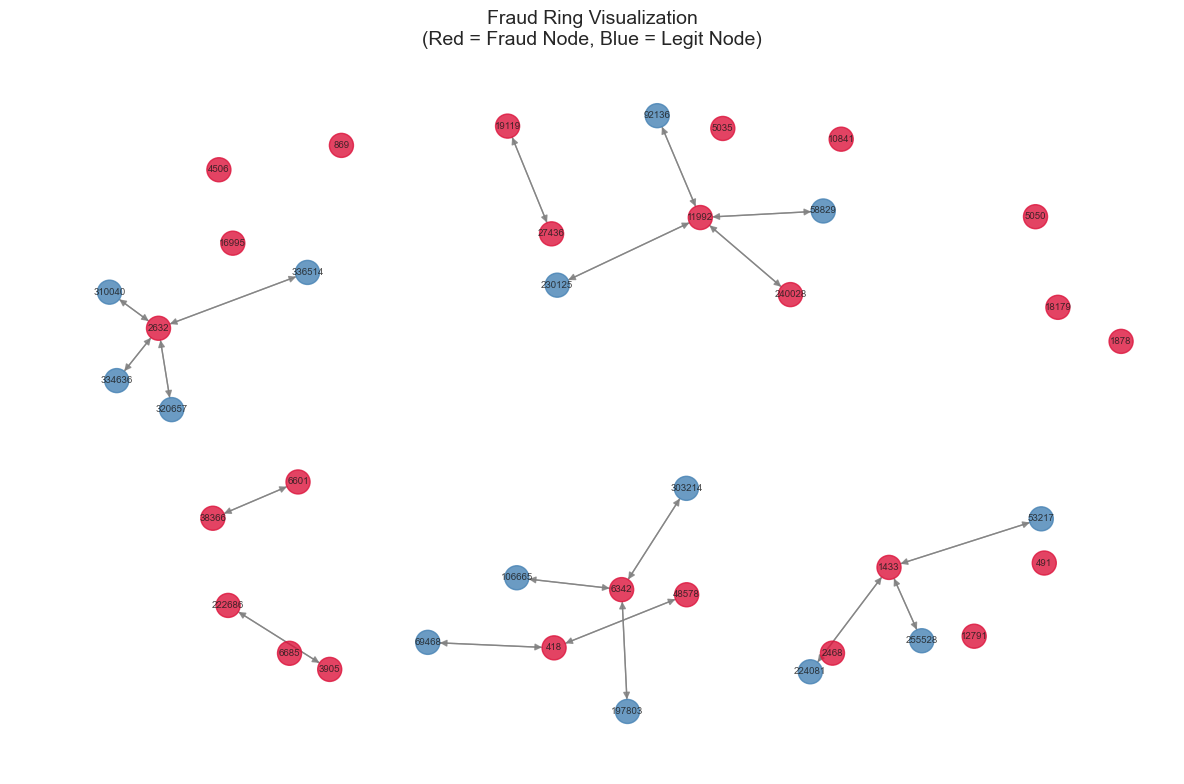

✅ Saved fraud_ring.png


In [18]:
import networkx as nx

fraud_node_ids = np.where(data.y.numpy() == 1)[0][:20]
sample_nodes   = set(fraud_node_ids.tolist())

edge_np = data.edge_index.numpy()
for fn in fraud_node_ids:
    neighbours = edge_np[1][edge_np[0] == fn][:5]
    sample_nodes.update(neighbours.tolist())

G = nx.DiGraph()
node_list = list(sample_nodes)
G.add_nodes_from(node_list)

for i in range(edge_np.shape[1]):
    s, d = edge_np[0, i], edge_np[1, i]
    if s in sample_nodes and d in sample_nodes:
        G.add_edge(s, d)

node_colors = ['crimson' if data.y[n].item() == 1
               else 'steelblue' for n in G.nodes()]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw_networkx(G, pos,
                 node_color=node_colors,
                 node_size=300,
                 font_size=7,
                 arrows=True,
                 edge_color='gray',
                 alpha=0.8)
plt.title('Fraud Ring Visualization\n(Red = Fraud Node, Blue = Legit Node)',
          fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('fraud_ring.png', dpi=150)
plt.show()
print("✅ Saved fraud_ring.png")

In [19]:
gnn_results = pd.DataFrame({
    'node_id'      : range(len(gnn_probs)),
    'fraud_prob'   : gnn_probs,
    'fraud_pred'   : gnn_preds,
    'actual_label' : data.y.numpy()
})
gnn_results.to_csv('gnn_scores.csv', index=False)

print("✅ Saved gnn_scores.csv")
print(f"   File size : {os.path.getsize('gnn_scores.csv') / 1024:.1f} KB")

✅ Saved gnn_scores.csv
   File size : 11819.9 KB


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ----------------------------------- -- 524.3/556.1 kB 266.4 kB/s eta 0:00:01
   -------------------------------------- 556.1/556.1 kB 265.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ---------------------------------------- 0.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
